<a href="https://colab.research.google.com/github/manuelcorrea212/Fisica-Computacional/blob/main/Taller_2_Fisica_Computacional_Manuel_Correa_2417815_3146.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 10. Taller 2

### A. Jugando con la precision en Python
1. Complete y depure `suma_seno` (sección 7, "B. Completar el algoritmo") si aún no lo ha hecho.
2. Genere la tabla de convergencia (como en la sección 7) para al menos 6 valores de $x$ entre $0$ y $4\pi$, incluyendo el número de iteraciones, la suma y el error relativo frente a `math.sin`.
3. Con los datos de la tabla del punto anterior, compare el error relativo de cada caso contra la tolerancia esperada $10^{-8}$: ¿en todos los valores de $x$ que probó el error relativo queda por debajo de esa tolerancia? Si en algún caso no es así, indique para cuáles valores de $x$ ocurre y explique a qué se debe.
4. Repita el experimento de la sección 7 para $x$ grande (por ejemplo, $x=100$) **sin** la reducción de periodicidad, y explique en una o dos frases qué está pasando numéricamente.
5. Compare su implementación recursiva con una versión "ingenua" que calcule cada término desde cero usando `math.factorial` y `x**potencia` — ¿en qué valores de $x$ empieza a notarse la diferencia de desempeño o de precisión?

### B. Decaimiento radiactivo con Python (Entregar Reporte)

Durante la semana anterior estudiamos el **decaimiento radiactivo utilizando FORTRAN**. En este ejercicio retomaremos el mismo sistema físico, pero utilizaremos Python para trabajar con un conjunto de valores, analizar los resultados y representarlos gráficamente.

El número de núcleos radiactivos presentes en una muestra evoluciona de acuerdo con

$$
N(t)=N_0e^{-\lambda t},
$$

donde $N_0$ es el número inicial de núcleos y $\lambda$ es la constante de decaimiento. Esta constante se relaciona con la vida media $t_{1/2}$ mediante

$$
\lambda=\frac{\ln(2)}{t_{1/2}}.
$$

Considere una muestra con

$$
N_0=10\,000
$$

núcleos radiactivos y una vida media de

$$
t_{1/2}=5\ \mathrm{años}.
$$

#### Actividades

1. Calcule la constante de decaimiento $\lambda$.

2. Utilice `numpy.linspace()` para crear un arreglo de tiempos entre **0 y 30 años**. Utilice un número suficiente de puntos para observar claramente la evolución de la muestra.

3. Calcule $N(t)$ para todos los valores del arreglo de tiempos utilizando las operaciones vectorizadas de NumPy.

   **No utilice un ciclo `for` para realizar este cálculo.**

4. Utilice `matplotlib` para representar gráficamente $N(t)$ en función del tiempo. La gráfica debe incluir:

   - título;
   - nombre de los ejes;
   - unidades;
   - una cuadrícula que facilite la lectura de los resultados.

5. Identifique sobre la gráfica los tiempos correspondientes a **una, dos y tres vidas medias**. Observe qué fracción de la muestra permanece después de cada una de ellas.

6. Determine aproximadamente el tiempo en el cual permanece:

   - el **50 %** de la muestra inicial;
   - el **25 %** de la muestra inicial;
   - el **10 %** de la muestra inicial.

**Objetivo del ejercicio:** aplicar las herramientas básicas de Python estudiadas esta semana a un problema físico conocido y comenzar a utilizar Python para el **manejo, análisis y visualización de resultados científicos**.

### C. Celda de verificación (PASS/FAIL)

Para agilizar la revisión, la tarea debe cerrar con una celda que compruebe automáticamente 2-3 casos conocidos e imprima PASS/FAIL — no hace falta rastrear la lógica a mano para calificar. Abajo hay una celda de verificación para la Parte A (usa `suma_seno_reducida`, ya definida en la sección 7) y una plantilla para la Parte B: complete `N_decaimiento` con $N(t) = N_0 e^{-\lambda t}$ y la celda le dirá si sus resultados coinciden con los valores esperados (recordando el caso de la vida media del carbono-14 de la Semana 1: al cabo de una vida media siempre queda el 50 % de la muestra).

## 7. Series e Iteraciones

### A. Suma de la serie de Taylor de $\sin(x)$

$$\sin(x) = x - \frac{x^3}{3!} + \frac{x^5}{5!} - \frac{x^7}{7!} + \cdots = \sum_{n=0}^{\infty} (-1)^n\frac{x^{2n+1}}{(2n+1)!}$$

**Objetivo:** calcular $\sin(x)$ sumando términos de la serie, deteniéndose cuando el **aporte del último término** sea menor que una tolerancia prescrita.

En vez de calcular cada término desde cero (factoriales y potencias grandes, caro y riesgoso), relacionamos cada término con el anterior. Si $t_0=x$, entonces:

$$t_n = -\,t_{n-1}\frac{x^2}{(2n)(2n+1)}, \qquad n=1,2,\ldots$$

### B. Completar el algoritmo

Completa los dos espacios en blanco: la fórmula recursiva del término y el criterio de parada. Para evitar problemas cuando la suma está cerca de cero, usa un criterio mixto del tipo

$$|t_n| < \mathrm{tol}\,\max(1,|S_n|).$$


# Solucion del taller

Pregunta A inciso 1

In [46]:
import math

def suma_seno(x, tol=1e-8, max_iter=200):            # Define una función para aproximar sin(x) mediante su serie de Taylor.
    term = x                                         # Inicializa el primer término de la serie: t_0 = x.
    total = x                                        # Inicializa la suma parcial con el primer término.
    n = 0                                            # Inicializa el índice usado para construir los términos siguientes.

    for i in range(max_iter):                        # Repite como máximo max_iter veces para evitar un ciclo infinito.
        n += 1                                       # Incrementa n antes de calcular el siguiente término de la serie.
        term = (-term * x**2)/((2 * n) * (2 * n + 1)) # COMPLETAR: usa la relación recursiva para calcular el nuevo término a partir del anterior.
        total = total + term                         # Añade el nuevo término a la suma parcial.

        if abs(term) < tol * max(1.0, abs(total)):                          # COMPLETAR: escribe el criterio de parada mixto basado en term, tol y total.
            break                                    # Sale del ciclo cuando el último término ya es suficientemente pequeño.

    return total, i + 1  # Devuelve la aproximación calculada y el número de iteraciones realizadas.

x_val = 1.5707963267948966  # Equivale a pi / 2
resultado, iteraciones = suma_seno(x_val)

print(f"Seno aproximado : {resultado}")
print(f"Iteraciones necesarias: {iteraciones}")
print(f"Valor exacto (math.sin): {math.sin(x_val)}")

Seno aproximado : 0.9999999999939768
Iteraciones necesarias: 7
Valor exacto (math.sin): 1.0


Pregunta A inciso 2,3,4,5

In [47]:
#--------------------------------Inciso 2---------------------------------------
import math
import time

def suma_seno(x, tol=1e-8, max_iter=200):            # Define una función para aproximar sin(x) mediante su serie de Taylor.
    term = x                                         # Inicializa el primer término de la serie: t_0 = x.
    total = x                                        # Inicializa la suma parcial con el primer término.
    n = 0                                            # Inicializa el índice usado para construir los términos siguientes.

    for i in range(max_iter):                        # Repite como máximo max_iter veces para evitar un ciclo infinito.
        n += 1                                       # Incrementa n antes de calcular el siguiente término de la serie.
        term = (-term * x**2)/((2 * n) * (2 * n + 1)) # COMPLETAR: usa la relación recursiva para calcular el nuevo término a partir del anterior.
        total = total + term                         # Añade el nuevo término a la suma parcial.

        if abs(term) < tol * max(1.0, abs(total)):                          # COMPLETAR: escribe el criterio de parada mixto basado en term, tol y total.
            break                                    # Sale del ciclo cuando el último término ya es suficientemente pequeño.

    return total, i + 1  # Devuelve la aproximación calculada y el número de iteraciones realizadas.

x_valores = [0.0, 1.5707, 3.1416, 4.7123, 6.2831, 7.8539, 9.4247, 10.9955, 12.5663]

print(f"{'x':>8} {'imax':>6} {'suma':>18} {'error relativo':>18}")
print("-" * 56)

for x in x_valores:
    approx, iters = suma_seno(x)
    exacto = math.sin(x)

    # Manejo si math.sin(x) está extremadamente cerca de 0 para evitar división por cero
    if abs(exacto) > 0:
        error_relativo = abs(approx - exacto) / abs(exacto)
    else:
        error_relativo = abs(approx - exacto)

    print(f"{x:8.4f} {iters:6d} {approx:18.10f} {error_relativo:18.2e}")
#---------------------------------Inciso 4--------------------------------------
x_grande = 100.0
approx, iters = suma_seno(x_grande)
exacto = math.sin(x_grande)

print(f"x = {x_grande}:")
print(f"  Aproximado : {approx}")
print(f"  Exacto     : {exacto}")
print(f"  Iteraciones: {iters}")

#------------------------------Inciso 5-----------------------------------------
x_test = 1.5707963267948966  # pi / 2
# Medición de tiempo de la versión ingenua
t0 = time.perf_counter()
res_ing, iter_ing = suma_seno_(x_test)
t1 = time.perf_counter()

print(f"Versión Ingenua Inciso 5 (con math.factorial):")
print(f"  Resultado:  {res_ing:.10f}")
print(f"  Iteraciones: {iter_ing}")
print(f"  Tiempo:      {(t1 - t0)*1e6:.2f} microsegundos")

#---------------------------------Pregunta C------------------------------------
# --- Verificación Parte A: suma_seno_reducida ---
casos_a = [                                        # Lista de (x, valor_esperado, tolerancia) para probar la Parte A.
    (0.5, math.sin(0.5), 1e-8),                    # Caso dentro del rango normal de convergencia rápida.
    (100.0, math.sin(100.0), 1e-6),                # Caso con x grande: solo debe pasar si se usó reducción de argumento.
    (-237.0, math.sin(-237.0), 1e-6),              # Caso con x grande y negativo.
]

for x, esperado, tol in casos_a:                   # Recorre cada caso de prueba uno por uno.
    obtenido, _ = suma_seno_reducida(x)             # Calcula sin(x) con la función que el estudiante debe haber completado.
    ok = abs(obtenido - esperado) < tol             # Compara contra el valor de referencia dentro de la tolerancia.
    estado = "PASS" if ok else "FAIL"               # Traduce el resultado booleano a texto legible.
    print(f"{estado}  x={x:>8.1f}   obtenido={obtenido: .10f}   esperado={esperado: .10f}")  # Imprime el veredicto de este caso.


       x   imax               suma     error relativo
--------------------------------------------------------
  0.0000      1       0.0000000000           0.00e+00
  1.5707      7       0.9999999954           6.02e-12
  3.1416     10      -0.0000073464           1.41e-06
  4.7123     12      -0.9999999959           1.34e-10
  6.2831     15      -0.0000853072           2.86e-07
  7.8539     17       0.9999999966           9.16e-11
  9.4247     19       0.0000779605           3.22e-06
 10.9955     21      -0.9999999978           5.66e-10
 12.5663     24      -0.0000706143           9.18e-07
x = 100.0:
  Aproximado : -8.261375671717164e+25
  Exacto     : -0.5063656411097588
  Iteraciones: 111
Versión Ingenua Inciso 5 (con math.factorial):
  Resultado:  1.0000000000
  Iteraciones: 8
  Tiempo:      74.67 microsegundos
PASS  x=     0.5   obtenido= 0.4794255386   esperado= 0.4794255386
PASS  x=   100.0   obtenido=-0.5063656411   esperado=-0.5063656411
PASS  x=  -237.0   obtenido= 0.981957869

Pregunta A inciso 3

No todos los valores dados quedan por debajo del error relativo 10$^{-8}$.  Estos valores son los enteros del numero pi ($\pi, 2\pi, 3\pi, 4\pi$) quedan en el orden de 10$^{-6} - 10^{-7}$. Mientras que para los valores donde el numero pi no es entero se cumple ($\pi/2, 3\pi/2, 5\pi/2, 7\pi/2$).

Esto sucede debido al que calcular el error relativo respecto al math.sin(x) cuando la funcion vale 0 (en los enteros de $\pi$), cualquier residuo absoluto (del orden de $10^{-11}$) al dividirse por la imprecisión del valor exacto infla artificialmente la cifra del error relativo.

Pregunta A inciso 4: Analisis

Al evaluar x=100 en la serie ocurre un fenomeno llamado cancelacion castratofica destructiva debido a 2 factores, la finites de precision de los puntos flotantes de 64 bits y a los terminos intermedios de la serie que  alcanzan magnitudes enormes (superando incluso $10^{38}$), por consiguiente se pierden las cifras significativas reales y devuelve un resultado inservible en el orden de miles de millones en vez del intervalo acotado en [-1,1]

Pregunta A inciso 5: Analisis

Analisis de rendimiento:
LA diferencia de rendimiento se empieza a notar conforme aumentan las interacciones ( n > 10 ), ademas, esta forma de calcular (ingenuamente) demora mas tiempo ya que por cada interaccion tiene que realizar un bucle $\mathcal{O}(n^2)$, mientras que de forma recursiva calcula el siguiente término en tiempo constante $\mathcal{O}(1)$ mediante un par de multiplicaciones y divisiones.

La version ingenua despues de muchas interacciones (85 o mas) empieza a arrojar un error OverflowError: integer division result too large for float al intentar convertir factoriales extremadamente grandes a punto flotante. La versión recursiva mantiene los números intermedios en rangos manejables sin desbordar el tipo de dato.

Pregunta B

1. Constante de decaimiento (lambda): 0.1386 años^-1

Evalución en Vidas Medias 
t =  5.0 años (1 t_1/2) -> N(t) = 5000.00 núcleos (Fracción restante: 0.500 o 50.0%)
t = 10.0 años (2 t_1/2) -> N(t) = 2500.00 núcleos (Fracción restante: 0.250 o 25.0%)
t = 15.0 años (3 t_1/2) -> N(t) = 1250.00 núcleos (Fracción restante: 0.125 o 12.5%)


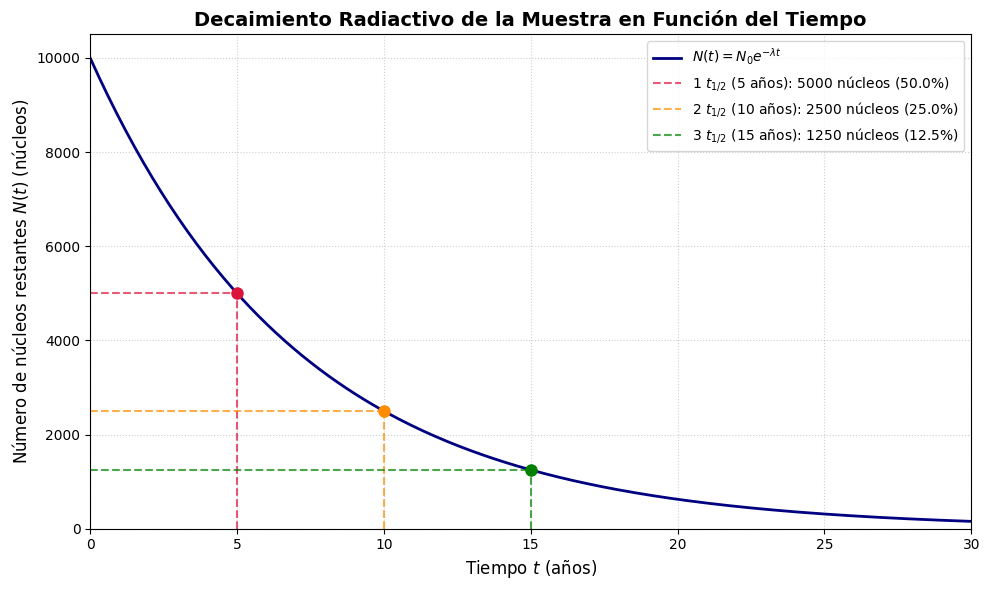

PASS  t=  0.0 años   fraccion=1.000   esperada=1.000
PASS  t=  5.0 años   fraccion=0.500   esperada=0.500
PASS  t= 10.0 años   fraccion=0.250   esperada=0.250


In [48]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Parámetros del problema
N0 = 10000        # Número inicial de núcleos radiactivos
t_half = 5.0      # Vida media en años

#--------------------------------Inciso 1---------------------------------------
lam = np.log(2) / t_half
print(f"1. Constante de decaimiento (lambda): {lam:.4f} años^-1\n")

# Definicion de N_decaimiento
def N_decaimiento(t, N0=10000, t_half=5.0):
    lam_local = np.log(2) / t_half
    return N0 * np.exp(-lam_local * t)
    print(f"Constante de decaimiento (lambda): {lam_local}")



#----------------------------------Inciso 2-------------------------------------
# Arreglo de tiempos y cálculo vectorizado de N(t)
# Se crean 300 puntos entre 0 y 30 años para una curva suave
t = np.linspace(0, 30, 300)

#----------------------------------Inciso 3-------------------------------------
#Cálculo vectorizado sin bucles for
N = N0 * np.exp(-lam * t)

#----------------------------------Inciso 4-------------------------------------
#Gráfica con Matplotlib e identificación de vidas medias
plt.figure(figsize=(10, 6))

# Curva de decaimiento
plt.plot(t, N, label=r'$N(t) = N_0 e^{-\lambda t}$', color='navy', linewidth=2)

#----------------------------------Incisio 5------------------------------------
# Vidas medias (1, 2 y 3 t_{1/2})
vidas_medias = [1, 2, 3]
colores_puntos = ['crimson', 'darkorange', 'green']

print("Evalución en Vidas Medias ")
for k, col in zip(vidas_medias, colores_puntos):
    t_k = k * t_half
    N_k = N0 * np.exp(-lam * t_k)
    fraccion = N_k / N0
    print(f"t = {t_k:4.1f} años ({k} t_1/2) -> N(t) = {N_k:7.2f} núcleos (Fracción restante: {fraccion:.3f} o {fraccion*100:.1f}%)")

    # Marcadores en la gráfica
    plt.plot(t_k, N_k, 'o', color=col, markersize=8)
    plt.vlines(x=t_k, ymin=0, ymax=N_k, color=col, linestyle='--', alpha=0.7)
    plt.hlines(y=N_k, xmin=0, xmax=t_k, color=col, linestyle='--', alpha=0.7,
               label=f'{k} $t_{{1/2}}$ ({t_k:.0f} años): {N_k:.0f} núcleos ({fraccion*100:.1f}%)')

# Configuración de la gráfica
plt.title('Decaimiento Radiactivo de la Muestra en Función del Tiempo', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo $t$ (años)', fontsize=12)
plt.ylabel('Número de núcleos restantes $N(t)$ (núcleos)', fontsize=12)
plt.xlim(0, 30)
plt.ylim(0, N0 * 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

#--------------------------------------------Pregunta C---------------------------------------------------------------------
# --- Parte B: complete N_decaimiento y luego corra la verificación ---

casos_b = [                                        # Lista de (t, fracción_esperada): fracción de N0 que debería quedar en cada instante.
    (0.0, 1.00),                                   # En t=0 debe quedar el 100% de la muestra.
    (5.0, 0.50),                                   # En t = t_1/2 (una vida media) debe quedar el 50%.
    (10.0, 0.25),                                  # En t = 2*t_1/2 (dos vidas medias) debe quedar el 25%.
]

for t, fraccion_esperada in casos_b:               # Recorre cada caso de prueba.
    try:                                           # Evita que un NotImplementedError detenga toda la celda de verificación.
        obtenido = N_decaimiento(t) / 10000        # Calcula qué fracción de N0 queda en el instante t.
        ok = abs(obtenido - fraccion_esperada) < 1e-3  # Compara contra la fracción esperada con tolerancia razonable.
        estado = "PASS" if ok else "FAIL"
        print(f"{estado}  t={t:>5.1f} años   fraccion={obtenido:.3f}   esperada={fraccion_esperada:.3f}")
    except NotImplementedError as e:               # Si aún no se ha completado la función, lo informa sin detener la celda.
        print(f"FAIL  t={t:>5.1f} años   ({e})")